# Morphology in BrainCell

This notebook is a gentle introduction to morphology building in `braincell`.

We will cover three common workflows:

1. Build individual branches from lengths and radii.
2. Assemble several branches into a full `Morphology` tree.
3. Import reconstructed morphologies from `SWC` and `ASC` files.

The goal here is to understand morphology itself: geometry, topology, simple inspection, and simple visualization.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")
import braincell
import brainunit as u
from braincell import Branch, Soma, Axon, BasalDendrite, ApicalDendrite, Morphology


In [2]:
# Keep any vis examples in this notebook aligned with the shared 2D/3D palette.
braincell.vis.configure_defaults(
    branch_type_colors={
        "soma": "#000000",
        "axon": "#1AE035",
        "basal_dendrite": "#f59212",
        "apical_dendrite": "#f26107",
        "dendrite": "#e30f0f",
        "custom": "#9aa4af",
    },
)


VisDefaults(layout_2d_default='fan', shape_2d_default='frustum', mode_3d_default='geometry', branch_type_colors={'soma': (0, 0, 0), 'axon': (26, 224, 53), 'basal_dendrite': (245, 146, 18), 'apical_dendrite': (242, 97, 7), 'dendrite': (227, 15, 15), 'custom': (154, 164, 175)}, branch_type_edge_colors_2d=None, alpha_2d=0.8, alpha_2d_poly=None, alpha_2d_line=None, frustum_edge_linewidth_2d=0.9, alpha_3d_tube=1.0, highlight_color=(255, 215, 0), highlight_alpha=0.9, marker_color=(30, 144, 255), marker_size_2d=36.0, marker_radius_3d_um=1.5)

## 1. `Branch`: the basic geometry unit

A `Branch` is one unbranched piece of neuronal cable. In BrainCell, a branch is represented as a sequence of frustum segments.

You can build a branch in two main ways:

- `Branch.from_lengths(...)`: useful when you know segment lengths and radii, but do not have 3D coordinates yet.
- `Branch.from_points(...)`: useful when you already have 3D points, as in reconstructed morphologies.

We start with `from_lengths(...)`. The key parameter is `lengths=[l0, ..., lN-1]`, which gives one length per segment.

Then you choose **one of two mutually exclusive radius styles**:

- `Branch.from_lengths(lengths=..., radii=[r0, ..., rN])`
- `Branch.from_lengths(lengths=..., radii_proximal=[rp0, ..., rpN-1], radii_distal=[rd0, ..., rdN-1])`

Here:

- `radii=[r0, ..., rN]` gives the shared radii at segment boundaries, which is the compact form when radius stays continuous across the branch
- `radii_proximal` and `radii_distal` give one proximal/distal radius pair per segment, which is more explicit when you want to describe each segment directly

So the first conceptual difference is not about branch type, but about how you want to describe radius along the cable.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


branch_from_paired == branch_from_shared: True

-----------------------------------
type         | custom
n_segments   | 1
length       | 20.00 um
mean_radius  | 10.00 um
area         | 1256.64 um^2
volume       | 6283.19 um^3
-----------------------------------



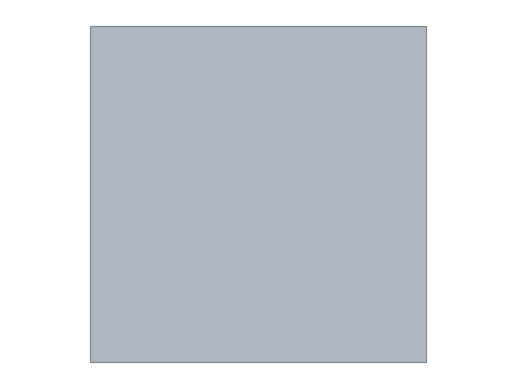

<Axes: >

In [3]:
# The following two branches represent the same one-segment geometry.
branch_from_paired = Branch.from_lengths(
    lengths=[20.0] * u.um,
    radii_proximal=[10.0] * u.um,
    radii_distal=[10.0] * u.um,
)

branch_from_shared = Branch.from_lengths(
    lengths=[20.0] * u.um,
    radii=[10.0, 10.0] * u.um,
)

print("branch_from_paired == branch_from_shared:", branch_from_paired == branch_from_shared)
print()
print(branch_from_paired)

# Length-based branches use the default schematic 2D layout.
branch_from_paired.vis2d()

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


-----------------------------------
type         | dendrite
n_segments   | 3
length       | 40.00 um
mean_radius  | 2.13 um
area         | 535.88 um^2
volume       | 598.66 um^3
-----------------------------------



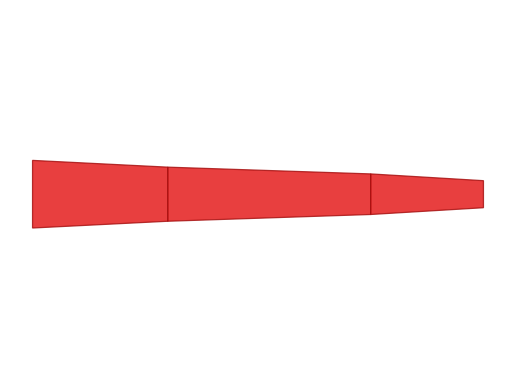

<Axes: >

In [4]:
# The same idea extends naturally to branches with multiple frustum segments.
multi_branch = Branch.from_lengths(
    lengths=[12.0, 18.0, 10.0] * u.um,
    radii=[3.0, 2.4, 1.8, 1.2] * u.um,
    type = 'dendrite'
)

print(multi_branch)
multi_branch.vis2d()

### Why keep both radius styles?

So for simple branches, the two radius styles are often interchangeable. The next question is why BrainCell keeps both of them.

Most of the time, `radii=[r0, ..., rN]` is the most readable form because adjacent segments share the same radius at each boundary.

However, morphology data sometimes contains an abrupt diameter change at a single location. In that case, the shared-node representation is no longer enough by itself, because one node would need two different radii.

That is exactly why `radii_proximal` and `radii_distal` exist: they let you describe a radius jump directly.

Below, `jump_paired` uses the paired-radius form to encode a discontinuity between the first and second segment. `jump_shared` encodes the same geometry by inserting a zero-length middle segment. The two branches are equivalent, but the paired form is easier to read.

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


jump_paired == jump_shared: True
paired proximal radii: [3. 2. 1.] um
paired distal radii: [2. 1. 1.] um
paired radii: [3. 2. 1. 1.] um
shared radii : [3. 2. 1. 1.] um


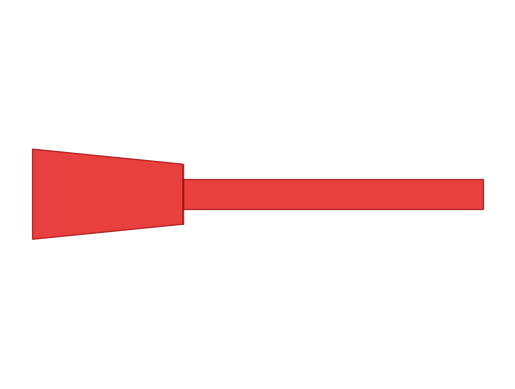

<Axes: >

In [5]:
jump_paired = Branch.from_lengths(
    lengths=[10.0, 20.0] * u.um,
    radii_proximal=[3.0, 1.0] * u.um,
    radii_distal=[2.0, 1.0] * u.um,
    type = 'dendrite'
)

jump_shared = Branch.from_lengths(
    lengths=[10.0, 0.0, 20.0] * u.um,
    radii=[3.0, 2.0, 1.0, 1.0] * u.um,
    type = 'dendrite'
)

print("jump_paired == jump_shared:", jump_paired == jump_shared)
print("paired proximal radii:", jump_paired.radii_proximal)
print("paired distal radii:", jump_paired.radii_distal)
print("paired radii:", jump_paired.radii)
print("shared radii :", jump_shared.radii)

jump_paired.vis2d()

## 2. `Branch.from_points(...)`: attach real 3D geometry

If you already know the 3D coordinates of a branch, `from_points(...)` is the better starting point.

In this case, BrainCell computes segment lengths automatically from consecutive points. Point geometry is what later unlocks projected 2D views, 3D views, and coordinate-based measurements.

For now, we still keep the example generic and use the default 2D view.

-----------------------------------
type         | dendrite
n_segments   | 3
length       | 47.55 um
mean_radius  | 2.03 um
area         | 606.97 um^2
volume       | 652.74 um^3
-----------------------------------

Computed segment lengths: [12.         18.         17.54992877] um
Shared points shape: (4, 3)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


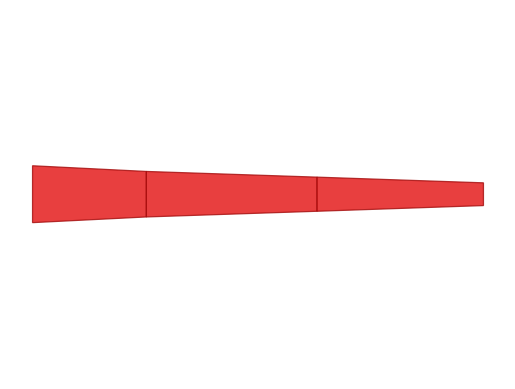

<Axes: >

In [6]:
point_branch = Branch.from_points(
    points=[(0.0, 0.0, 0.0), (12.0, 0.0, 0.0), (12.0, 18.0, 0.0), (16.0, 34.0, 6.0)] * u.um,
    radii=[3.0, 2.4, 1.8, 1.2] * u.um, type = 'dendrite'
)

print(point_branch)
print("Computed segment lengths:", point_branch.lengths)
print("Shared points shape:", point_branch.points.shape)

point_branch.vis2d()

### Useful `Branch` attributes

At this point we have seen both length-based and point-based branch construction. The table below summarizes the main public attributes you will inspect most often while building morphology.

| Attribute | Description |
| --- | --- |
| `lengths` | Length of each frustum segment (`N` values) |
| `length` | Total branch length |
| `areas` | Surface area of each segment (`N` values) |
| `area` | Total surface area of the branch |
| `volumes` | Volume of each segment (`N` values) |
| `volume` | Total branch volume |
| `mean_radius` | Length-weighted mean radius |
| `radii_proximal` | Proximal radius of each segment (`N` values) |
| `radii_distal` | Distal radius of each segment (`N` values) |
| `radii` | Shared node radii (`N + 1` values) when boundaries are continuous |
| `points_proximal` | Start point of each segment (`N` points) |
| `points_distal` | End point of each segment (`N` points) |
| `points` | Shared node coordinates (`N + 1` points) when point geometry is continuous |
| `type` | Branch type such as `soma`, `axon`, or dendrite variants |
| `n_segments` | Number of frustum segments |

For branches created with `from_lengths(...)`, the point-related attributes are `None`. For branches created with `from_points(...)`, those point-related attributes are populated.

In [7]:
# Total cable length across all segments.
print("multi_branch length:", multi_branch.length)

# Length of each individual frustum segment.
print("multi_branch lengths:", multi_branch.lengths)

# Surface area of each segment and the total area.
print("multi_branch areas:", multi_branch.areas)
print("multi_branch area:", multi_branch.area)

# Volume of each segment and the total volume.
print("multi_branch volumes:", multi_branch.volumes)
print("multi_branch volume:", multi_branch.volume)

# A compact summary of branch thickness.
print("multi_branch mean_radius:", multi_branch.mean_radius)

# Radius information stored per segment boundary and per segment end.
print("multi_branch radii:", multi_branch.radii)
print("multi_branch radii_proximal:", multi_branch.radii_proximal)
print("multi_branch radii_distal:", multi_branch.radii_distal)

# This branch came from from_lengths(...), so explicit point geometry is absent.
print("multi_branch points:", multi_branch.points)

# For a point-based branch, the shared nodes and segment endpoints are available.
print("point_branch points shape:", point_branch.points.shape)
print("point_branch points_proximal shape:", point_branch.points_proximal.shape)
print("point_branch points_distal shape:", point_branch.points_distal.shape)

multi_branch length: 40. um
multi_branch lengths: [12. 18. 10.] um
multi_branch areas: [203.82951763 237.63631763  94.41727315] um^2
multi_branch area: 535.8831 um^2
multi_branch volumes: [275.95750804 251.07609135  71.6283122 ] um^3
multi_branch volume: 598.6619 um^3
multi_branch mean_radius: 2.13 um
multi_branch radii: [3.         2.4000001  1.79999995 1.20000005] um
multi_branch radii_proximal: [3.         2.4000001  1.79999995] um
multi_branch radii_distal: [2.4000001  1.79999995 1.20000005] um
multi_branch points: None
point_branch points shape: (4, 3)
point_branch points_proximal shape: (3, 3)
point_branch points_distal shape: (3, 3)


## 3. Build a `Morphology` tree by hand

A `Morphology` is a mutable tree whose nodes are branches.

At this stage, branch identity starts to matter. BrainCell therefore provides typed branch constructors such as `Soma`, `Axon`, `Dendrite`, `BasalDendrite`, `ApicalDendrite`, and `CustomBranch`. They are convenience wrappers over `Branch(..., type=...)`.

The usual pattern is:

1. Create a root with `Morphology.from_root(...)`.
2. Attach children with one of the supported syntaxes.

Below we use three attachment styles on purpose, because you will see all of them in real code:

- `tree.soma.basal = branch`
- `tree.attach(...)`
- `tree.soma[parent_x, child_x].axon = branch`

A few rules are worth remembering:

- `parent_x` can be `0`, `0.5`, or `1`
- `parent_x=0.5` is only allowed on a soma
- `child_x` can currently be `0` or `1`

### Understanding `tree.attach(...)`

`tree.attach(...)` is the most explicit way to insert a child branch into a morphology tree.

Its main parameters are:

- `parent`: the existing branch you want to attach onto, usually given by name such as `"soma"`
- `child_branch`: the branch object being inserted into the tree
- `child_name`: the name used inside the tree; if omitted, BrainCell can auto-generate one, but explicit names are easier to read in tutorials
- `parent_x`: where the connection is made on the parent branch
- `child_x`: which end of the child branch is used for the connection

For attachment positions:

- `parent_x=0` means the proximal end of the parent branch
- `parent_x=0.5` means the midpoint of the parent branch, and this is only allowed for a soma
- `parent_x=1` means the distal end of the parent branch
- `child_x=0` means attach using the child branch's proximal end
- `child_x=1` means attach using the child branch's distal end

For example, `tree.attach(parent="soma", child_branch=basal_main, child_name="basal_main", parent_x=1.0)` means: attach the proximal end of `basal_main` to the distal end of `soma`, and store the new branch under the name `basal_main`.

In [8]:
point_soma = Soma.from_points(
    points=[(0.0, 0.0, 0.0), (12.0, 0.0, 0.0)] * u.um,
    radii=[6.0, 6.0] * u.um,
)

basal_main = BasalDendrite.from_points(
    points=[(12.0, 0.0, 0.0), (26.0, 8.0, 0.0), (40.0, 14.0, 0.0)] * u.um,
    radii=[2.6, 2.0, 1.4] * u.um,
)

basal_side = BasalDendrite.from_points(
    points=[(12.0, 0.0, 0.0), (24.0, -10.0, 0.0), (36.0, -18.0, 0.0)] * u.um,
    radii=[2.2, 1.7, 1.2] * u.um,
)

apical_upper = ApicalDendrite.from_points(
    points=[(40.0, 14.0, 0.0), (52.0, 26.0, 4.0), (64.0, 38.0, 8.0)] * u.um,
    radii=[1.4, 1.0, 0.7] * u.um,
)

apical_lower = ApicalDendrite.from_points(
    points=[(40.0, 14.0, 0.0), (52.0, 10.0, 4.0), (64.0, 6.0, 8.0)] * u.um,
    radii=[1.3, 0.95, 0.7] * u.um,
)

axon = Axon.from_points(
    points=[(0.0, 0.0, 0.0), (-12.0, -6.0, 0.0), (-26.0, -14.0, -2.0)] * u.um,
    radii=[1.0, 0.8, 0.6] * u.um,
)

tree = Morphology.from_root(point_soma, name="soma")

tree.attach(parent="soma", child_branch=basal_main, child_name="basal_main", parent_x=1.0)
tree.attach(parent="soma", child_branch=basal_side, child_name="basal_side", parent_x=1.0)
tree.attach(parent="basal_main", child_branch=apical_upper, child_name="apical_upper", parent_x=1.0)
tree.attach(parent="basal_main", child_branch=apical_lower, child_name="apical_lower", parent_x=1.0)

# Here the axon is attached to the proximal end of the soma, so it extends to the left.
tree.soma[0.0, 0.0].axon = axon

print(tree)
print(tree.topo())

-----------------------------------
root         | soma
n_branches   | 6
geometry     | complete 3d points
length       | 164.47 um
area         | 1705.91 um^2
volume       | 2311.03 um^3
-----------------------------------

soma
├── basal_main
│   ├── apical_upper
│   └── apical_lower
├── basal_side
└── axon


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


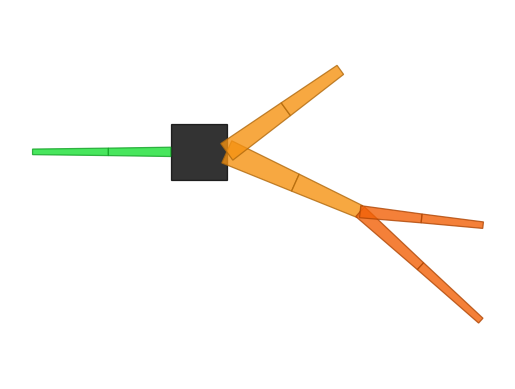

<Axes: >

In [9]:
tree.vis2d()

### Inspect the tree

For quick inspection, the most useful tools are usually:

- `print(tree)` for a short summary
- `tree.metric` for a metric snapshot
- `tree.topo()` for a readable topology tree
- `tree.branch(...)` and `tree.branch_by_order(...)` for queries

In [10]:
print(tree.metric)
print("Has full point geometry:", tree.has_full_point_geometry)
print("Branch names in default order:", [branch.name for branch in tree.branches])
print("Branch 1 in default order:", tree.branch(index=1))
print("Branch named 'apical_upper':", tree.branch(name="apical_upper"))
print("Path from the root to branch 3:", tree.path_to_root(3))

-----------------------------------
n_branches       | 6
n_stems          | 3
n_bifurcations   | 2
max_branch_order | 2
total_length     | 164.47 um
mean_radius      | 1.65 um
total_area       | 1705.91 um^2
total_volume     | 2311.03 um^3
max_path_dist    | 78.23 um
-----------------------------------

Has full point geometry: True
Branch names in default order: ['soma', 'basal_main', 'basal_side', 'apical_upper', 'apical_lower', 'axon']
Branch 1 in default order: MorphoBranch(name='basal_main', type='basal_dendrite', index=1)
Branch named 'apical_upper': MorphoBranch(name='apical_upper', type='apical_dendrite', index=3)
Path from the root to branch 3: (0, 1, 3)


### What does `tree.metric` mean?

`tree.metric` is a compact snapshot of whole-tree summary measurements.

| Field | Meaning |
| --- | --- |
| `n_branches` | Total number of branches in the morphology |
| `n_stems` | Number of primary branches that leave the root |
| `n_bifurcations` | Number of branching points in the tree |
| `max_branch_order` | Largest branch depth measured from the root |
| `total_length` | Sum of the lengths of all branches |
| `mean_radius` | Length-weighted mean radius across the whole tree |
| `total_area` | Total membrane surface area across all branches |
| `total_volume` | Total cable volume across all branches |
| `max_path_distance` | Longest path length from the root to any point in the tree |
| `max_path_distance_excluding_soma` | Same as above, but excluding the soma contribution |
| `max_euclidean_distance` | Largest straight-line distance from the root, available only when full point geometry exists |
| `max_euclidean_distance_excluding_soma` | Largest straight-line distance excluding the soma, available only when full point geometry exists |
| `x_range` | Span of x coordinates, available only when full point geometry exists |
| `y_range` | Span of y coordinates, available only when full point geometry exists |
| `z_range` | Span of z coordinates, available only when full point geometry exists |
| `has_full_point_geometry` | Whether every branch in the tree carries explicit point geometry |

In other words, the path-based fields are always useful for topology-aware cable measurements, while the Euclidean-distance and coordinate-range fields only exist when the full tree has explicit 3D points.

### A note on 3D

This hand-built tree already has full point geometry, so the same morphology can be rendered directly in 3D. Because the coordinates were chosen explicitly, the axon extends to the left, while the basal and apical dendrites extend to the right.

For notebook-based docs, `notebook=True` embeds the scene in the cell output, and `jupyter_backend="html"` saves a static interactive HTML view that works in headless builds.

<interactive PyVista scene>
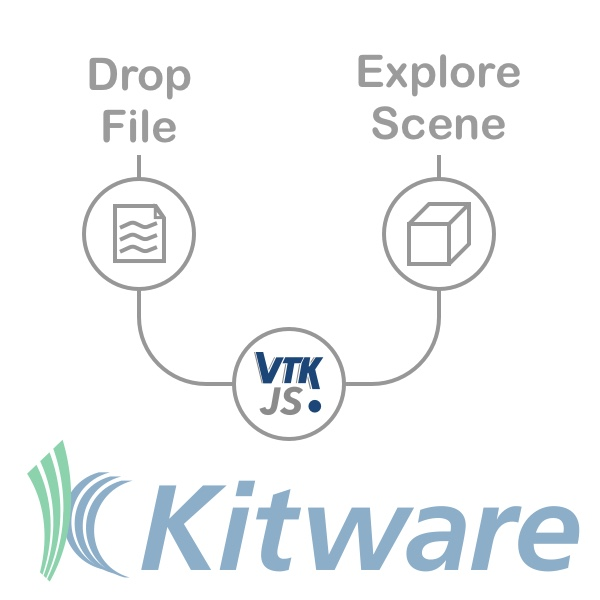

In [11]:
tree.vis3d(notebook=True, jupyter_backend="html")

## 4. Import morphology from files

In practice, many morphologies come from reconstruction files rather than hand-written code.

This notebook only shows the basic entry points:

- `Morphology.from_swc(path)`
- `Morphology.from_asc(path)`

We keep the examples deliberately simple here. Detailed file-format semantics and reader diagnostics will be covered in a separate module.

-----------------------------------
n_branches       | 9
n_stems          | 2
n_bifurcations   | 3
max_branch_order | 3
total_length     | 219.78 um
mean_radius      | 1.43 um
total_area       | 1973.69 um^2
total_volume     | 1885.06 um^3
max_path_dist    | 89.09 um
-----------------------------------

soma
├── axon_0
│   └── axon_1
└── basal_dendrite_0
    ├── basal_dendrite_1
    │   ├── basal_dendrite_2
    │   └── basal_dendrite_3
    ├── basal_dendrite_4
    └── basal_dendrite_5


<interactive PyVista scene>
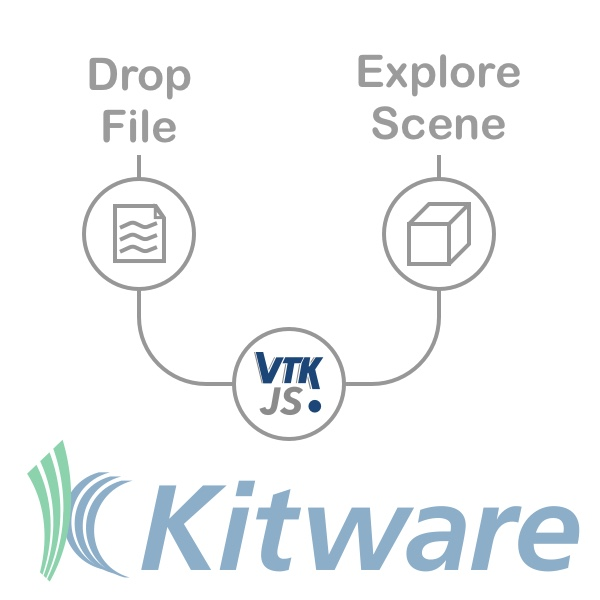

In [12]:
swc_tree = Morphology.from_swc("../../data/morphology/example_tree.swc")

print(swc_tree.metric)
print(swc_tree.topo())

swc_tree.vis3d(notebook=True, jupyter_backend="html")

### ASC: the same idea

`ASC` loading follows the same pattern. We keep it equally simple: load the file, inspect the morphology, and draw it with the default 2D view.

--No graphics will be displayed.
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [6]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [8]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_points() produced 1 zero-length segment(s) from coincident consecutive points at index pair(s) [4]. These degenerate segments are kept but contribute zero volume.
  return branch_class_for_type(segment.branch_type).from_points(
/home/swl/braincell/braincell/io/asc/reader.py:584: UserWarning: from_poi

-----------------------------------
n_branches       | 461
n_stems          | 1
n_bifurcations   | 228
max_branch_order | 25
total_length     | 4464.31 um
mean_radius      | 0.51 um
total_area       | 14475.19 um^2
total_volume     | 7832.98 um^3
max_path_dist    | 227.89 um
-----------------------------------



Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


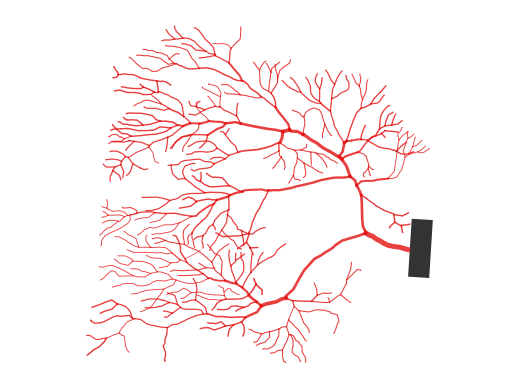

<interactive PyVista scene>
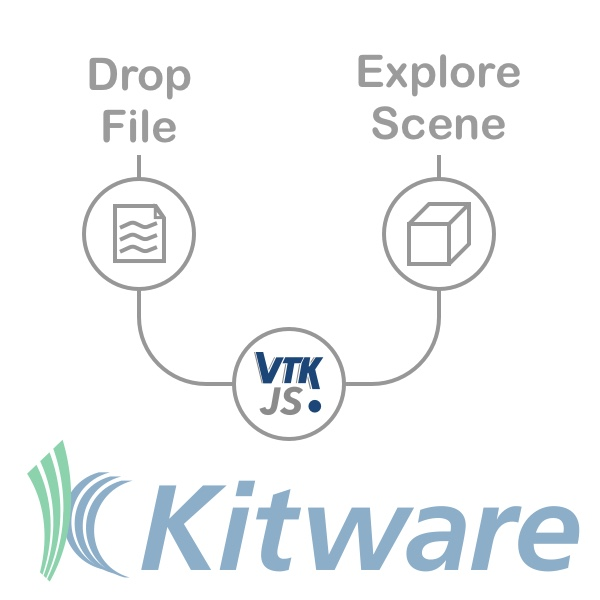

In [13]:
asc_tree = Morphology.from_asc("../../data/morphology/pc.asc")

print(asc_tree.metric)

asc_tree.vis2d(layout='projected', shape='line')
asc_tree.vis3d(notebook=True, jupyter_backend="html")

## Summary

You have now seen the core morphology workflow in BrainCell:

- Build single branches with `from_lengths(...)` or `from_points(...)`.
- Compare `radii` with `radii_proximal` / `radii_distal`, including a radius-jump example.
- Inspect `Branch` attributes, topology, and morphology-level metrics.
- Assemble an editable `Morphology` tree from those branches, including typed branch wrappers such as `Soma` and `Axon`.
- Import reconstructed morphologies from `SWC` and `ASC` files with the basic entry points.

A good next step is `cell.ipynb`, where morphology becomes the structural input to a multi-compartment cell model.